In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import re
import json
from math import pi
from datetime import timedelta

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose

from Tools import Tools4DataExtraction as T4DE

In [2]:
D4NN= T4DE.Get_Data4NN_p()
atributo='FECHA_CORRIDA'
atributo1= 'FECHA_OPERACION'
D4NN[atributo1] = pd.to_datetime(D4NN[atributo1])
fecha_maxima = D4NN[atributo1].max()
dia_anterior = fecha_maxima - timedelta(days=1)
"""
fecha_inicio = dia_anterior - timedelta(days=364)
D4NN = D4NN[(D4NN[atributo1] >= fecha_inicio) &
                    (D4NN[atributo1] <= dia_anterior)].copy()
"""
D4NN = D4NN[(D4NN[atributo1] <= dia_anterior)].copy()

#D4NN= D4NN[D4NN['TIPO_PASAJERO']=='AD'].copy()

Memoria usada antes: 632.97 MB
Memoria usada después: 122.94 MB
Reducción: 80.6%


In [3]:
D4NN.columns

Index(['OPERACION', 'TRANSACCION', 'FECHA_OPERACION', 'HORA_OPERACION',
       'NOMBRE_DIA_OPERACION', 'AREA_VENTA', 'CLASE_SERVICIO', 'ORIGEN',
       'DESTINO', 'CV_CORRIDA', 'FECHA_CORRIDA', 'HORA_SALIDA_CORRIDA',
       'TIPO_PASAJERO', 'TIPO_CLIENTE', 'TIPO_OPERACION', 'VENTA_ANTICIPADA',
       'NOMBRE_PASAJERO', 'NUM_ASIENTO', 'PORCENT_PROMO', 'DESC_DESCUENTO',
       'BOLETOS_CANCEL', 'BOLETOS_TOTALES', 'BOLETOS_VEND', 'VENTA_CANCEL',
       'IVA_CANCEL', 'IVA_VENDIDO', 'VENTA_TOTAL', 'VENTA', 'CV_ASIGN',
       'ORIGEN_CORRIDA', 'DESTINO_CORRIDA', 'CAPACIDAD_ASIENTOS_TRAMO',
       'KMS_TRAMO', 'EMPRESA', 'TIPO_CORRIDA', 'TIPO_BUS',
       'HORA_SALIDA_ORIGEN_CORRIDA', 'KMS_ACUM_CORRIDA', 'NOMBRE_DIA_CORRIDA',
       'TARIFA_BASE_TRAMO', 'IVA_TARIFA_BASE_TRAMO', 'INGRESO_TRANSP',
       'IVA_TRANSP', 'DISPONIBILIDAD_TRAMO', 'OCUPACION_TRAMO', 'PAX_BAJAN',
       'PAX_SUBEN', 'TARJETA', 'EFECTIVO', 'EMAIL', 'PAGO_METODO',
       'TOTAL_BOLETOS', 'TOTAL_VENTA', 'DIF_TARIF', 'HOR

# Algoritmo para ventas


RMSE:31102.81  MAPE:12.97%  R2:0.8100


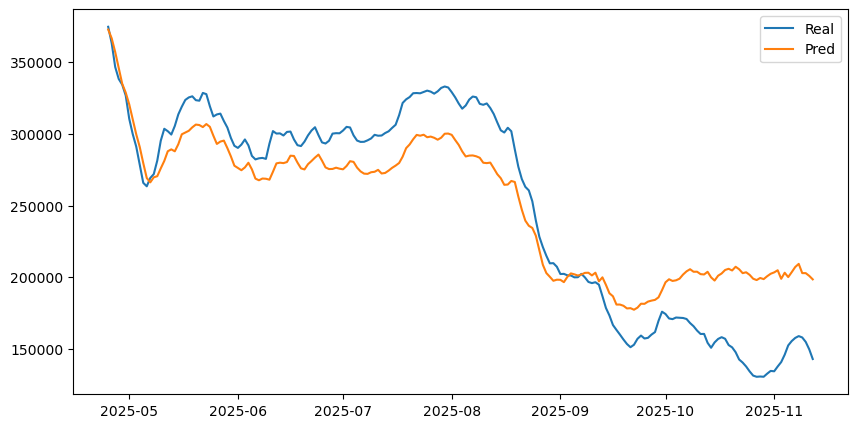

In [4]:
# -------------------------
# Preparar datos base
# -------------------------
target_col = 'VENTA'
Frame = D4NN[[atributo1, target_col, 'MES', 'FOP', 'PORCENT_PROMO','HORAS_ANTICIPACION']].copy()

# ---- AGREGACIÓN ----
agg_dict = {col: 'mean' for col in Frame.columns if col not in [atributo1, target_col]}
agg_dict[target_col] = 'sum'  # target siempre suma

df = Frame.groupby(atributo1).agg(agg_dict).reset_index()

df = df.set_index(atributo1)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

df_finalFore = pd.DataFrame()
df_finalFore[target_col] = df[target_col].copy()

# ---- DESCOMPOSICIÓN ----
result = seasonal_decompose(df[target_col], model='additive', period=14)
df['trend'] = result.trend
df['DiaSemana'] = df.index.dayofweek

# ---- JSON FEATURES ----
def Get_goodCarac(Df, BC_json):
    df = Df.copy()
    df['DiaMayorBoletaje'] = df['DiaSemana'].isin(BC_json["DiaBueno"])
    df['MesMayorBoletaje'] = df['MES'].isin(BC_json["MesBueno"])
    return df

ruta_principal = os.getcwd()
BuenasCarac_path = os.path.join(ruta_principal, "Files", "BuenaCaracteristicas.json")
with open(BuenasCarac_path, 'r') as f:
    BC_json = json.load(f)

df = Get_goodCarac(df, BC_json)

# ---- Crear objetivo = diferencias del trend ----
df['trend_diff'] = df['trend'].diff()

# ---- LAGS y medias móviles ----
df["diff_lag1"]  = df["trend_diff"].shift(1)
df["diff_lag7"]  = df["trend_diff"].shift(7)
df["diff_lag30"] = df["trend_diff"].shift(30)
df["diff_ma7"]  = df["trend_diff"].rolling(7).mean()
df["diff_ma30"] = df["trend_diff"].rolling(30).mean()

# ---- FEATURES CÍCLICAS ----
df["sin_mes"] = np.sin(2 * np.pi * df["MES"] / 12)
df["cos_mes"] = np.cos(2 * np.pi * df["MES"] / 12)
df["sin_dia"] = np.sin(2 * np.pi * df["DiaSemana"] / 7)
df["cos_dia"] = np.cos(2 * np.pi * df["DiaSemana"] / 7)

# ---- LISTA FINAL DE FEATURES (INCLUYE PORCENT_PROMO) ----
features = [
    "diff_lag1", "diff_lag7", "diff_lag30",
    "diff_ma7", "diff_ma30",
    "sin_dia", "cos_dia", "sin_mes", "cos_mes",
    "DiaMayorBoletaje", "MesMayorBoletaje",
    "FOP", "PORCENT_PROMO",'HORAS_ANTICIPACION'
]

df = df.dropna()

X = df[features]
y = df["trend_diff"]

# ---- TRAIN/TEST ----
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# ---- MODELO ----
model = XGBRegressor(
    n_estimators=800, learning_rate=0.03,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, objective="reg:squarederror"
)
model.fit(X_train, y_train)

# ---- PRED TEST ----
y_pred_diff = model.predict(X_test)

# ---- RECONSTRUCCIÓN TREND ----
last_trend_train = df['trend'].iloc[train_size - 1]
trend_pred_level = np.cumsum(y_pred_diff) + last_trend_train
trend_real_level = df["trend"].iloc[train_size:].values
idx_test = df.index[train_size:]

rmse = np.sqrt(mean_squared_error(trend_real_level, trend_pred_level))
mape = mean_absolute_percentage_error(trend_real_level, trend_pred_level) * 100
r2 = r2_score(trend_real_level, trend_pred_level)

print(f"\nRMSE:{rmse:.2f}  MAPE:{mape:.2f}%  R2:{r2:.4f}")

plt.figure(figsize=(10,5))
plt.plot(idx_test, trend_real_level, label='Real')
plt.plot(idx_test, trend_pred_level, label='Pred')
plt.legend()
plt.show()


In [ ]:
from statsmodels.tsa.seasonal import STL
from sklearn.model_selection import TimeSeriesSplit

# -------------------------
# Preparar datos base
# -------------------------
target_col = 'VENTA'
Frame = D4NN[[atributo1, target_col, 'MES', 'FOP', 'PORCENT_PROMO','HORAS_ANTICIPACION']].copy()

# ---- AGREGACIÓN ----
agg_dict = {col: 'mean' for col in Frame.columns if col not in [atributo1, target_col]}
agg_dict[target_col] = 'sum'  # target siempre suma

df = Frame.groupby(atributo1).agg(agg_dict).reset_index()

df = df.set_index(atributo1)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# ---- DESCOMPOSICIÓN MÁS ROBUSTA (STL) ----
stl = STL(df[target_col], period=14, robust=True)
result = stl.fit()
df['trend'] = result.trend

# ---- FEATURES TEMPORALES ----
df['DiaSemana'] = df.index.dayofweek
df['Mes'] = df.index.month
df['SemanaAño'] = df.index.isocalendar().week.astype(int)

# ---- AUTOCORRELACIONES PRINCIPALES ----
from statsmodels.tsa.stattools import acf
acf_vals = acf(df['trend'].dropna(), nlags=40)
top_lags = np.argsort(np.abs(acf_vals))[1:6]  # 5 lags con mayor autocorr

for lag in top_lags:
    df[f"lag_auto_{lag}"] = df["trend"].shift(lag)

# ---- DYNAMICS (momentum + aceleración) ----
df["trend_diff"]   = df["trend"].diff()
df["trend_accel"]  = df["trend_diff"].diff()

# ---- MEDIAS MÓVILES ----
for w in [7, 14, 30]:
    df[f"diff_ma{w}"]  = df["trend_diff"].rolling(w).mean()
    df[f"trend_ma{w}"] = df["trend"].rolling(w).mean()

# ---- CÍCLICAS MEJORADAS ----
df["sin_dia"] = np.sin(2 * np.pi * df["DiaSemana"] / 7)
df["cos_dia"] = np.cos(2 * np.pi * df["DiaSemana"] / 7)
df["sin_mes"] = np.sin(2 * np.pi * df["Mes"] / 12)
df["cos_mes"] = np.cos(2 * np.pi * df["Mes"] / 12)

# ---- TARGET ENCODING ----
df["avg_venta_dia"] = df.groupby("DiaSemana")[target_col].transform("mean")
df["avg_venta_mes"] = df.groupby("Mes")[target_col].transform("mean")

# ---- INTERACCIONES ----
df["promo_x_horas"] = df["PORCENT_PROMO"] * df["HORAS_ANTICIPACION"]
df["fop_x_promo"]  = df["FOP"] * df["PORCENT_PROMO"]

df = df.dropna()

# ---- FEATURES FINAL ----
features = [c for c in df.columns if c not in [target_col, "trend"]]

X = df[features]
y = df["trend_diff"]

# ---- VALIDACIÓN TEMPORAL ----
tscv = TimeSeriesSplit(n_splits=5)
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.02,
        max_depth=5,
        subsample=0.75,
        colsample_bytree=0.7,
        reg_alpha=0.5,
        reg_lambda=2,
        objective="reg:squarederror"
    )

    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

    y_pred = model.predict(X_test)

# ---- FIT FINAL ----
model.fit(X, y)

# ---- PREDICTION TEST LAST BLOCK ----
y_pred_diff = model.predict(X.iloc[-len(X_test):])

# ---- Reconstrucción del trend ----
last_trend = df['trend'].iloc[-len(X_test)-1]
trend_pred = np.cumsum(y_pred_diff) + last_trend

real_trend = df['trend'].iloc[-len(X_test):].values
idx_plot = df.index[-len(X_test):]

print("\nR2 final:", r2_score(real_trend, trend_pred))

plt.plot(idx_plot, real_trend, label="Real",color='black',lw=4)
plt.plot(idx_plot, trend_pred,'r-', label="Predicho",lw=1)
plt.legend()
plt.show()


In [ ]:
# -------------------------
target_col= 'VENTA'
Frame = D4NN[[atributo,target_col]].copy()

agg_dict = {col: 'mean' for col in Frame.columns if col not in [atributo,target_col]}
agg_dict[target_col] = 'sum'

df1 = Frame.groupby(atributo).agg(agg_dict).reset_index()
df1

In [ ]:
# -------------------------
target_col= 'VENTA'
Frame = D4NN[[atributo1,target_col]].copy()

agg_dict = {col: 'mean' for col in Frame.columns if col not in [atributo1,target_col]}
agg_dict[target_col] = 'sum'

df = Frame.groupby(atributo1).agg(agg_dict).reset_index()
df

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df.index, 
    y=df.VENTA,
    mode='lines',
    name='operacion'
))

fig.add_trace(go.Scatter(
    x=df1.index, 
    y=df1.VENTA,
    mode='lines',
    name='corrida'
))

fig.update_layout(
    title="Ventas",
    xaxis_title="Fecha",
    yaxis_title="Venta",
    hovermode="x unified"
)

fig.show()


# Algoritmo chido

In [ ]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
import json, os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

# =====================================================
# 1. DATA PREPARATION
# =====================================================

def load_and_aggregate(D4NN, target_col):
    Frame = D4NN[['FECHA_OPERACION', target_col, 'MES', 'PORCENT_PROMO', 'FOP','HORAS_ANTICIPACION']].copy()
    agg_dict = {col:'mean' for col in Frame.columns if col not in ['FECHA_OPERACION', target_col]}
    agg_dict[target_col] = 'sum'
    df = Frame.groupby('FECHA_OPERACION').agg(agg_dict)
    df.index = pd.to_datetime(df.index)
    return df.sort_index()


def add_seasonal_and_calendar(df, target_col):
    # ---- STL ----
    stl = STL(df[target_col], period=14, robust=True)
    result = stl.fit()
    df['trend'] = result.trend

    df['DiaSemana'] = df.index.dayofweek
    df['Mes'] = df.index.month
    df['SemanaAño'] = df.index.isocalendar().week.astype(int)

    df["sin_mes"] = np.sin(2*np.pi*df["Mes"]/12)
    df["cos_mes"] = np.cos(2*np.pi*df["Mes"]/12)
    df["sin_dia"] = np.sin(2*np.pi*df["DiaSemana"]/7)
    df["cos_dia"] = np.cos(2*np.pi*df["DiaSemana"]/7)

    return df, result


def add_business_features(df, json_path):
    with open(json_path, 'r') as f:
        BC = json.load(f)

    df['DiaMayorBoletaje'] = df['DiaSemana'].isin(BC["DiaBueno"])
    df['MesMayorBoletaje'] = df['Mes'].isin(BC["MesBueno"])
    return df, BC


def add_diff_features(df):
    # ---- Autocorrelaciones ----
    acf_vals = acf(df['trend'].dropna(), nlags=40)
    top_lags = np.argsort(np.abs(acf_vals))[1:6]

    for lag in top_lags:
        df[f"lag_auto_{lag}"] = df["trend"].shift(lag)

    # ---- Momentum y aceleración ----
    df["trend_diff"] = df["trend"].diff()
    df["trend_accel"] = df["trend_diff"].diff()

    # ---- Lags originales del pipeline ----
    df["diff_lag1"] = df["trend_diff"].shift(1)
    df["diff_lag7"] = df["trend_diff"].shift(7)
    df["diff_lag30"] = df["trend_diff"].shift(30)

    # ---- Medias móviles ----
    for w in [7,30]:
        df[f"diff_ma{w}"] = df["trend_diff"].rolling(w).mean()
        df[f"trend_ma{w}"] = df["trend"].rolling(w).mean()

    # ---- Target encoding ----
    df["avg_venta_dia"] = df.groupby("DiaSemana")["trend"].transform("mean")
    df["avg_venta_mes"] = df.groupby("Mes")["trend"].transform("mean")

    # ---- Interacciones ----
    df["promo_x_horas"] = df["PORCENT_PROMO"] * df["HORAS_ANTICIPACION"]
    df["fop_x_promo"]  = df["FOP"] * df["PORCENT_PROMO"]

    return df.dropna()


# =====================================================
# 2. TRAINING
# =====================================================

def build_train_test(df, feature_cols, target="trend_diff", test_ratio=0.2):
    X = df[feature_cols]
    y = df[target]
    split = int(len(df)*(1-test_ratio))
    return X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:], split


def train_xgboost(X_train, y_train):
    model = XGBRegressor(
        n_estimators=1200, learning_rate=0.02, max_depth=5,
        subsample=0.75, colsample_bytree=0.7, 
        reg_alpha=0.5, reg_lambda=2, objective="reg:squarederror"
    )
    model.fit(X_train, y_train)
    return model


def reconstruct_trend(df, y_pred, split):
    last = df['trend'].iloc[split-1]
    trend_pred = np.cumsum(y_pred) + last
    trend_real = df["trend"].iloc[split:].values
    return trend_real, trend_pred


# =====================================================
# 3. FUTURE FORECAST
# =====================================================

def forecast_autoregressive(df, model, BC_json, days=15):
    last_date = df.index[-1]
    future = pd.DataFrame(index=pd.date_range(last_date+pd.Timedelta(1), periods=days))

    future["Mes"] = future.index.month
    future["DiaSemana"] = future.index.dayofweek

    future["sin_mes"] = np.sin(2*np.pi*future["Mes"]/12)
    future["cos_mes"] = np.cos(2*np.pi*future["Mes"]/12)
    future["sin_dia"] = np.sin(2*np.pi*future["DiaSemana"]/7)
    future["cos_dia"] = np.cos(2*np.pi*future["DiaSemana"]/7)

    future["DiaMayorBoletaje"] = future["DiaSemana"].isin(BC_json["DiaBueno"])
    future["MesMayorBoletaje"] = future["Mes"].isin(BC_json["MesBueno"])

    future["PORCENT_PROMO"] = df["PORCENT_PROMO"].iloc[-1]
    future["FOP"] = df["FOP"].iloc[-1]

    diffs = []
    last_trend = df["trend"].iloc[-1]
    last_diff = df["trend_diff"].iloc[-1]

    for i in range(days):
        row = pd.DataFrame({
            "diff_lag1":[last_diff],
            "diff_lag7":[df["trend_diff"].iloc[-7+i] if i<7 else diffs[i-7]],
            "diff_lag30":[df["trend_diff"].iloc[-30+i] if i<30 else diffs[i-30]],
            "diff_ma7":[df["trend_diff"].iloc[-7:].mean()],
            "diff_ma30":[df["trend_diff"].iloc[-30:].mean()],
            "sin_dia":[future["sin_dia"].iloc[i]],
            "cos_dia":[future["cos_dia"].iloc[i]],
            "sin_mes":[future["sin_mes"].iloc[i]],
            "cos_mes":[future["cos_mes"].iloc[i]],
            "DiaMayorBoletaje":[future["DiaMayorBoletaje"].iloc[i]],
            "MesMayorBoletaje":[future["MesMayorBoletaje"].iloc[i]],
            "PORCENT_PROMO":[future["PORCENT_PROMO"].iloc[i]],
            "FOP":[future["FOP"].iloc[i]],
        })

        pred = model.predict(row)[0]
        diffs.append(pred)
        last_trend += pred
        last_diff = pred

    future["pred_trend"] = np.cumsum(diffs) + df["trend"].iloc[-1]
    return future


def apply_garch_intervals(resid, future_df, seasonal, alpha=0.99):
    am = arch_model(resid, mean='Zero', vol='Garch', p=1, q=1, dist='t').fit(disp='off')
    var = am.forecast(horizon=len(future_df), reindex=False).variance.values[-1]
    std = np.sqrt(var)

    from scipy.stats import t
    nu = am.params.get("nu", None)
    q = t.ppf(1-(1-alpha)/2, nu) if nu else 1.96

    future_df["upper"] = future_df["pred_trend"] + q*std
    future_df["lower"] = future_df["pred_trend"] - q*std

    future_df["forecast_final"] = future_df["pred_trend"] + seasonal
    future_df["forecast_upper"] = future_df["upper"] + seasonal
    future_df["forecast_lower"] = future_df["lower"] + seasonal
    future_df["volatility"] = std
    return future_df


# =====================================================
# 4. ORQUESTACIÓN (Pipeline maestro)
# =====================================================

def run_forecast_pipeline(D4NN, target_col, json_path, future_days=15):

    df = load_and_aggregate(D4NN, target_col)

    df_final = df[[target_col]].copy()
    df_final[target_col+"_FORE"] = df[[target_col]].copy()
    df_final["FORE_LOWER"] = df[[target_col]].copy()
    df_final["FORE_UPPER"] = df[[target_col]].copy()

    df, result = add_seasonal_and_calendar(df, target_col)
    df, BC_json = add_business_features(df, json_path)
    df = add_diff_features(df)

    feature_cols = [
        "diff_lag1","diff_lag7","diff_lag30","diff_ma7","diff_ma30",
        "sin_dia","cos_dia","sin_mes","cos_mes",
        "DiaMayorBoletaje","MesMayorBoletaje","PORCENT_PROMO","FOP"
    ]

    Xtr,Xts,ytr,yts,split = build_train_test(df, feature_cols)
    model = train_xgboost(Xtr,ytr)
    pred = model.predict(Xts)
    real, recon = reconstruct_trend(df, pred, split)

    from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
    rmse = np.sqrt(mean_squared_error(real, recon))
    mape = mean_absolute_percentage_error(real, recon) * 100
    r2 = r2_score(real, recon)

    print("\n📌 Métricas:")
    print("RMSE:", rmse)
    print("MAPE:", mape)
    print("R2:", r2)

    resid = real - recon

    fut = forecast_autoregressive(df, model, BC_json, future_days)
    seas = np.resize(result.seasonal[-14:].values, future_days)
    fut = apply_garch_intervals(resid, fut, seas)

    fut.index = fut.index.round("s")
    df_final.index = df_final.index.round("s")
    idx = fut.index.intersection(df_final.index)

    df_final.loc[idx, target_col+"_FORE"] = fut.loc[idx, "forecast_final"]
    df_final.loc[idx, "FORE_UPPER"] = fut.loc[idx, "forecast_upper"]
    df_final.loc[idx, "FORE_LOWER"] = fut.loc[idx, "forecast_lower"]
    df_final = df_final.fillna(0)

    return df_final, fut, model


# ================= EJECUCIÓN =================

ruta_principal = os.getcwd()
BuenasCarac_path = os.path.join(ruta_principal, "Files", "BuenaCaracteristicas.json")

df_forecast, future_df, model = run_forecast_pipeline(
    D4NN,
    target_col="VENTA",
    json_path=BuenasCarac_path,
    future_days=15
)


In [ ]:
df_forecast

In [ ]:
# =====================================================
# 1. DATA PREPARATION
# =====================================================
def load_and_aggregate(D4NN, target_col):
    Frame = D4NN[['FECHA_OPERACION', target_col, 'MES', 'PORCENT_PROMO', 'FOP']].copy()
    agg_dict = {col:'mean' for col in Frame.columns if col not in ['FECHA_OPERACION', target_col]}
    agg_dict[target_col] = 'sum'
    
    df = Frame.groupby('FECHA_OPERACION').agg(agg_dict)
    df.index = pd.to_datetime(df.index)
    return df.sort_index()


def add_seasonal_and_calendar(df, target_col):
    result = seasonal_decompose(df[target_col], model='additive', period=14)
    df['trend'] = result.trend
    df['DiaSemana'] = df.index.dayofweek

    df["sin_mes"] = np.sin(2*np.pi*df["MES"]/12)
    df["cos_mes"] = np.cos(2*np.pi*df["MES"]/12)
    df["sin_dia"] = np.sin(2*np.pi*df["DiaSemana"]/7)
    df["cos_dia"] = np.cos(2*np.pi*df["DiaSemana"]/7)

    return df, result


def add_business_features(df, json_path):
    with open(json_path, 'r') as f:
        BC = json.load(f)
    df['DiaMayorBoletaje'] = df['DiaSemana'].isin(BC["DiaBueno"])
    df['MesMayorBoletaje'] = df['MES'].isin(BC["MesBueno"])
    return df, BC


def add_diff_features(df):
    df['trend_diff'] = df['trend'].diff()
    df["diff_lag1"]  = df["trend_diff"].shift(1)
    df["diff_lag7"]  = df["trend_diff"].shift(7)
    df["diff_lag30"] = df["trend_diff"].shift(30)

    df["diff_ma7"]  = df["trend_diff"].rolling(7).mean()
    df["diff_ma30"] = df["trend_diff"].rolling(30).mean()
    return df.dropna()


# =====================================================
# 2. TRAINING
# =====================================================
def build_train_test(df, feature_cols, target="trend_diff", test_ratio=0.2):
    X = df[feature_cols]
    y = df[target]
    split = int(len(df)*(1-test_ratio))
    return X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:], split


def train_xgboost(X_train, y_train):
    model = XGBRegressor(
        n_estimators=800, learning_rate=0.03,
        max_depth=6, subsample=0.8, colsample_bytree=0.8
    )
    model.fit(X_train, y_train)
    return model


def reconstruct_trend(df, y_pred, split):
    last = df['trend'].iloc[split-1]
    trend_pred = np.cumsum(y_pred) + last
    trend_real = df["trend"].iloc[split:].values
    return trend_real, trend_pred


# =====================================================
# 3. FUTURE FORECAST
# =====================================================
def forecast_autoregressive(df, model, BC_json, days=15):
    last_date = df.index[-1]
    future = pd.DataFrame(index=pd.date_range(last_date+pd.Timedelta(1), periods=days))

    # calendar
    future["MES"] = future.index.month
    future["DiaSemana"] = future.index.dayofweek
    future["sin_mes"] = np.sin(2*np.pi*future["MES"]/12)
    future["cos_mes"] = np.cos(2*np.pi*future["MES"]/12)
    future["sin_dia"] = np.sin(2*np.pi*future["DiaSemana"]/7)
    future["cos_dia"] = np.cos(2*np.pi*future["DiaSemana"]/7)

    # business rules
    future["DiaMayorBoletaje"] = future["DiaSemana"].isin(BC_json["DiaBueno"])
    future["MesMayorBoletaje"] = future["MES"].isin(BC_json["MesBueno"])

    # exogenas (naive)
    future["PORCENT_PROMO"] = df["PORCENT_PROMO"].iloc[-1]
    future["FOP"] = df["FOP"].iloc[-1]

    # autoregressive loop
    diffs, last_trend, last_diff = [], df["trend"].iloc[-1], df["trend_diff"].iloc[-1]

    for i in range(days):
        row = pd.DataFrame({
            "diff_lag1":[last_diff],
            "diff_lag7":[df["trend_diff"].iloc[-7+i] if i<7 else diffs[i-7]],
            "diff_lag30":[df["trend_diff"].iloc[-30+i] if i<30 else diffs[i-30]],
            "diff_ma7":[df["trend_diff"].iloc[-7:].mean()],
            "diff_ma30":[df["trend_diff"].iloc[-30:].mean()],
            "sin_dia":[future["sin_dia"].iloc[i]],
            "cos_dia":[future["cos_dia"].iloc[i]],
            "sin_mes":[future["sin_mes"].iloc[i]],
            "cos_mes":[future["cos_mes"].iloc[i]],
            "DiaMayorBoletaje":[future["DiaMayorBoletaje"].iloc[i]],
            "MesMayorBoletaje":[future["MesMayorBoletaje"].iloc[i]],
            "PORCENT_PROMO":[future["PORCENT_PROMO"].iloc[i]],
            "FOP":[future["FOP"].iloc[i]],
        })

        pred = model.predict(row)[0]
        diffs.append(pred)
        last_trend += pred
        last_diff = pred

    future["pred_trend"] = np.cumsum(diffs) + df["trend"].iloc[-1]
    return future


def apply_garch_intervals(resid, future_df, seasonal, alpha=0.99):
    am = arch_model(resid, mean='Zero', vol='Garch', p=1, q=1, dist='t').fit(disp='off')
    var = am.forecast(horizon=len(future_df), reindex=False).variance.values[-1]
    std = np.sqrt(var)

    from scipy.stats import t
    nu = am.params.get("nu", None)
    q = t.ppf(1-(1-alpha)/2, nu) if nu else 1.96

    future_df["upper"] = future_df["pred_trend"] + q*std
    future_df["lower"] = future_df["pred_trend"] - q*std

    future_df["forecast_final"] = future_df["pred_trend"] + seasonal
    future_df["forecast_upper"] = future_df["upper"] + seasonal
    future_df["forecast_lower"] = future_df["lower"] + seasonal
    future_df["volatility"] = std
    return future_df


# =====================================================
# 4. ORQUESTACIÓN (Pipeline maestro)
# =====================================================
def run_forecast_pipeline(D4NN, target_col, json_path, future_days=15):

    df = load_and_aggregate(D4NN, target_col)
    df_final = df[[target_col]].copy()
    df_final[target_col+"_FORE"]= df[[target_col]].copy()
    df_final["FORE_LOWER"]= df[[target_col]].copy()
    df_final["FORE_UPPER"]= df[[target_col]].copy()
    
    df, result = add_seasonal_and_calendar(df, target_col)
    df, BC_json = add_business_features(df, json_path)
    df = add_diff_features(df)

    feature_cols = [
      "diff_lag1","diff_lag7","diff_lag30","diff_ma7","diff_ma30",
      "sin_dia","cos_dia","sin_mes","cos_mes","DiaMayorBoletaje",
      "MesMayorBoletaje","PORCENT_PROMO","FOP"
    ]

    # --- Train / predict ---
    Xtr,Xts,ytr,yts,split = build_train_test(df, feature_cols)
    model = train_xgboost(Xtr,ytr)

    pred = model.predict(Xts)
    real, recon = reconstruct_trend(df, pred, split)

    # --- Evaluación: RMSE, MAPE, R² sobre niveles del trend reconstruido ---
    from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
    rmse = np.sqrt(mean_squared_error(real, recon))
    mape = mean_absolute_percentage_error(real, recon) * 100
    r2   = r2_score(real, recon)

    print("\n📊 RESULTADOS XGBoost (Diferencias → Trend reconstruido) — EVALUACIÓN:")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"R²   : {r2:.6f}")

    resid = real - recon

    # --- Forecast futuro y GARCH ---
    fut = forecast_autoregressive(df, model, BC_json, future_days)
    seas = np.resize(result.seasonal[-14:].values, future_days)
    fut = apply_garch_intervals(resid, fut, seas)

    # ✅ CORRECCIÓN: normalizar índices para evitar nanosegundos raros
    fut.index = fut.index.round("s")
    df_final.index = df_final.index.round("s")

    # ✅ Intersección segura (solo índices que existen en df_final)
    idx = fut.index.intersection(df_final.index)

    # ✅ Asignación sin riesgo de KeyError
    df_final.loc[idx, target_col+"_FORE"] = fut.loc[idx, "forecast_final"]
    df_final.loc[idx, "FORE_UPPER"] = fut.loc[idx, "forecast_upper"]
    df_final.loc[idx, "FORE_LOWER"] = fut.loc[idx, "forecast_lower"]

    df_final= df_final.fillna(0)

    return df_final, fut, model


ruta_principal = os.getcwd()
BuenasCarac_path = os.path.join(ruta_principal, "Files", "BuenaCaracteristicas.json")

df_forecast, future_df, model = run_forecast_pipeline(
    D4NN,
    target_col="VENTA",
    json_path=BuenasCarac_path,
    future_days=15
)

In [ ]:
df_forecast